# House Prices: Advanced Regression Techniques

## 1. Introduction

This notebook explores the popular Kaggle competition, [House Prices: Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques), as both a predictive modeling challenge and a portfolio project.

The objective of this competition is to predict final house sale prices in Ames, Iowa, based on a variety of features such as location, size, and quality. This project will showcase a complete data science workflow—including Exploratory Data Analysis (EDA), feature engineering, model building, and evaluation. By documenting each step, I aim to both maximize prediction accuracy and clearly demonstrate my skills for potential employers or collaborators.

**Goals of this project:**
- **Deep Dive EDA:** Uncover patterns and insights to inform modeling choices.
- **Thoughtful Feature Engineering:** Use domain knowledge and data exploration to create new features and improve predictive power.
- **Reproducibility:** Maintain clear, reproducible code, always preserving original datasets and working with copies for all transformations.
- **Submission:** Prepare a Kaggle submission and reflect on what worked, what didn’t, and what could be improved.
- **Portfolio Quality:** Clearly explain decisions, show visualizations, and follow best practices in data science.

Let's get started!


## 2. Data Loading and Overview

In this section, I will load the train and test datasets provided by Kaggle. To ensure reproducibility and maintain data integrity, I will always keep the original datasets unchanged. All further analysis and transformations will be performed on copies.

Let's start by importing the necessary libraries and loading the data.


In [2]:
# Importing basic libraries
import pandas as pd
import numpy as np

# Load the original datasets
train_orig = pd.read_csv('train.csv')
test_orig = pd.read_csv('test.csv')

# Always work with copies to preserve the original data
train = train_orig.copy()
test = test_orig.copy()

# Display basic information about the datasets
print("Train shape:", train.shape)
print("Test shape:", test.shape)

# Preview the first few rows of the training data
train.head()


Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Notes:**
- The training dataset contains the `SalePrice` target column, which we will try to predict.
- The test dataset does not contain `SalePrice` and will be used for generating final predictions for Kaggle submission.

Next, I'll explore the basic structure and check for missing values to inform further analysis and EDA.


### 2.1 Dataset Overview

Before diving deeper, it's important to understand the structure of our data. Here, I'll review the feature names, data types, and check for missing values in both datasets.


In [3]:
# List columns and types
print("Columns in train set:")
print(train.dtypes.value_counts())
print("\nSample columns:", train.columns[:10].tolist())


Columns in train set:
object     43
int64      35
float64     3
Name: count, dtype: int64

Sample columns: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities']


From this output, we can quickly spot which features are categorical or numerical, and which have missing values. This will guide our EDA and preprocessing steps.

---

**Next Step:**  
I’ll begin the EDA by visualizing and summarizing key variables, distributions, and relationships—focusing first on the target variable `SalePrice` and then exploring features that may impact price.


## 3. Exploratory Data Analysis (EDA)

A good EDA will reveal key insights about the data, help us spot issues, and guide our feature engineering.  
We'll start by exploring the target variable, `SalePrice`, and then investigate some of the features with missing values, as well as other important variables.

### 3.1 Target Variable: SalePrice

Let's look at the distribution and basic statistics for `SalePrice`.


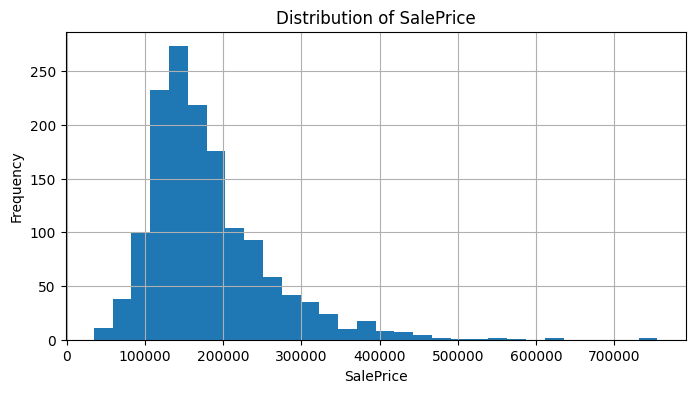

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [4]:
import matplotlib.pyplot as plt

# SalePrice distribution
plt.figure(figsize=(8,4))
train['SalePrice'].hist(bins=30)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

# Basic statistics
print(train['SalePrice'].describe())


### 3.2 Top Correlated Features with SalePrice

To help guide our feature engineering, let's look at which numerical features have the strongest linear relationship with `SalePrice`.


In [5]:
# Compute correlations with SalePrice, sort and display top 10
correlations = train.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False)
top_corr_features = correlations[1:50]  # Exclude SalePrice itself

print("Top 10 features most correlated with SalePrice:\n")
print(top_corr_features)


Top 10 features most correlated with SalePrice:

OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
KitchenAbvGr     0.135907
EnclosedPorch    0.128578
ScreenPorch      0.111447
PoolArea         0.092404
MSSubClass       0.084284
OverallCond      0.077856
MoSold           0.046432
3SsnPorch        0.044584
YrSold           0.028923
LowQualFinSF     0.025606
Id               0.021917
MiscVal          0.021190
BsmtHalfBath     0.016844
BsmtFinSF2     

**What Does Correlation with the Target Imply?**

The correlation coefficient measures the linear relationship between a feature and the target variable (`SalePrice`).  
- **A higher absolute correlation value (closer to 1 or -1)** suggests a stronger linear relationship.
- **Positive values** mean as the feature increases, `SalePrice` tends to increase as well.
- **Negative values** mean as the feature increases, `SalePrice` tends to decrease.

For example:
- `OverallQual` (overall material and finish quality) has the highest correlation with `SalePrice` (0.79), indicating that better-quality houses tend to sell for more.
- `GrLivArea` (above-ground living area), `GarageCars`, `GarageArea`, and `TotalBsmtSF` also show strong positive correlations, meaning bigger and better houses typically have higher prices.

**Important:**  
- **High correlation does not guarantee causation**—it just signals a relationship worth considering for modeling.
- XGBoost can also handle nonlinear relationships, but features with higher correlation to the target are usually strong candidates for predictive modeling.



### 3.3 Analyzing Missing Data

Next, let's see which features have the most missing values. This helps us decide how to handle them (e.g., fill, drop, or engineer new features based on missingness).


Top features with missing values in the training set:

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64


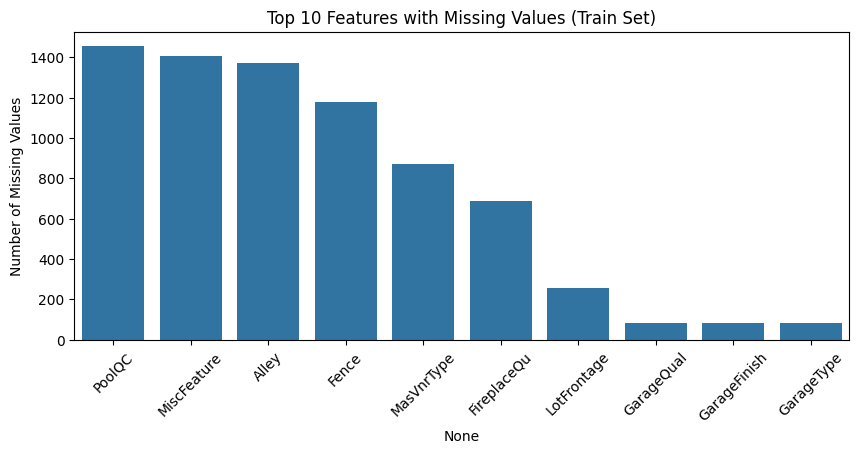

In [6]:
# Show top features with missing values in train set
missing_train = train.isnull().sum().sort_values(ascending=False)
print("Top features with missing values in the training set:\n")
print(missing_train.head(10))

# Visualize missing values (optional)
import seaborn as sns
plt.figure(figsize=(10,4))
sns.barplot(
    x=missing_train.head(10).index, 
    y=missing_train.head(10).values
)
plt.title('Top 10 Features with Missing Values (Train Set)')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()


### 3.4 Dropping Columns with Excessive Missingness

Features with too many missing values (e.g., >50%) provide little useful information and can be safely dropped.


In [7]:
# Define columns to drop
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']

# Create new datasets (v1) with selected columns dropped
train_v1 = train.drop(cols_to_drop, axis=1)
test_v1 = test.drop(cols_to_drop, axis=1)



#### 3.5 Impute LotFrontage Using Neighborhood Median

Missing `LotFrontage` values will be filled with the median value for each `Neighborhood`.  
If any remain missing, we’ll fill them with the overall median.


In [8]:
# Make copies for the next version
train_v2 = train_v1.copy()
test_v2 = test_v1.copy()

# Fill with neighborhood median
for df in [train_v2, test_v2]:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )
    # If any still missing, fill with overall median
    df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())


#### 3.5.1 Checking Remaining Missing Values

After handling the most problematic missing values and imputing `LotFrontage` using the neighborhood median, we’ll now review which features still contain missing data in our current datasets (`train_v2`, `test_v2`).  
This step helps us monitor progress and guides the next phase of data cleaning and imputation.


In [9]:
# Check missing values in the latest datasets
missing_train_v2 = train_v2.isnull().sum().sort_values(ascending=False)
missing_test_v2 = test_v2.isnull().sum().sort_values(ascending=False)

print("Top missing values in train_v2:")
print(missing_train_v2[missing_train_v2 > 0].head(10))

print("\nTop missing values in test_v2:")
print(missing_test_v2[missing_test_v2 > 0].head(10))


Top missing values in train_v2:
GarageType      81
GarageYrBlt     81
GarageQual      81
GarageCond      81
GarageFinish    81
BsmtFinType2    38
BsmtExposure    38
BsmtQual        37
BsmtFinType1    37
BsmtCond        37
dtype: int64

Top missing values in test_v2:
GarageQual      78
GarageCond      78
GarageFinish    78
GarageYrBlt     78
GarageType      76
BsmtCond        45
BsmtQual        44
BsmtExposure    44
BsmtFinType1    42
BsmtFinType2    42
dtype: int64


#### 3.5.2 Imputing Garage Feature Missing Values

The garage-related columns have missing values that typically indicate the absence of a garage.  
For categorical features, we'll fill with `'None'`; for the numerical year (`GarageYrBlt`), we'll fill with `0`.  
These changes are made in new datasets to preserve previous versions.


In [10]:
# Create new datasets for this change
train_v3 = train_v2.copy()
test_v3 = test_v2.copy()

# Categorical garage columns
garage_cat = ['GarageType', 'GarageQual', 'GarageCond', 'GarageFinish']
for col in garage_cat:
    train_v3[col] = train_v3[col].fillna('None')
    test_v3[col] = test_v3[col].fillna('None')

# Numerical garage column
train_v3['GarageYrBlt'] = train_v3['GarageYrBlt'].fillna(0)
test_v3['GarageYrBlt'] = test_v3['GarageYrBlt'].fillna(0)

train_v3['GarageArea'] = train_v3['GarageArea'].fillna(0)
test_v3['GarageArea'] = test_v3['GarageArea'].fillna(0)

train_v3['GarageCars'] = train_v3['GarageCars'].fillna(0)
test_v3['GarageCars'] = test_v3['GarageCars'].fillna(0)

#### Check: Do train and test datasets have the same columns (except target)?

It’s important to make sure our train and test datasets remain compatible after each preprocessing step.


In [11]:
# Check column equality (excluding the target 'SalePrice')
train_cols = set(train_v3.columns) - {'SalePrice'}
test_cols = set(test_v3.columns)

if train_cols == test_cols:
    print("✅ Train and test datasets have the same columns (except 'SalePrice').")
else:
    print("⚠️ Columns differ between train and test datasets:")
    print("In train but not test:", train_cols - test_cols)
    print("In test but not train:", test_cols - train_cols)


✅ Train and test datasets have the same columns (except 'SalePrice').


#### 3.5.3 Imputing Basement Feature Missing Values

Missing values in basement features usually indicate no basement.  
We will fill missing categorical basement columns with `'None'`, and numerical columns with `0` in new datasets.


In [12]:
# Make new datasets
train_v4 = train_v3.copy()
test_v4 = test_v3.copy()

# Basement categorical columns
bsmt_cat = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in bsmt_cat:
    train_v4[col] = train_v4[col].fillna('None')
    test_v4[col] = test_v4[col].fillna('None')

# Basement numerical columns (add more if you find missing ones during checks)
bsmt_num = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']
for col in bsmt_num:
    train_v4[col] = train_v4[col].fillna(0)
    test_v4[col] = test_v4[col].fillna(0)


In [13]:
# Column alignment check
train_cols = set(train_v4.columns) - {'SalePrice'}
test_cols = set(test_v4.columns)

if train_cols == test_cols:
    print("✅ Train and test datasets have the same columns (except 'SalePrice').")
else:
    print("⚠️ Columns differ between train and test datasets:")
    print("In train but not test:", train_cols - test_cols)
    print("In test but not train:", test_cols - train_cols)


✅ Train and test datasets have the same columns (except 'SalePrice').


#### 3.5.4 Checking for Remaining Missing Values

After handling basement features, let's review which features still have missing values in our latest datasets.  
This ensures our data is getting cleaner with every step.


In [14]:
# Check remaining missing values
missing_train_v4 = train_v4.isnull().sum().sort_values(ascending=False)
missing_test_v4 = test_v4.isnull().sum().sort_values(ascending=False)

print("Top missing values in train_v4:")
print(missing_train_v4[missing_train_v4 > 0].head(10))

print("\nTop missing values in test_v4:")
print(missing_test_v4[missing_test_v4 > 0].head(10))


Top missing values in train_v4:
MasVnrArea    8
Electrical    1
dtype: int64

Top missing values in test_v4:
MasVnrArea     15
MSZoning        4
Functional      2
Utilities       2
Exterior1st     1
Exterior2nd     1
SaleType        1
KitchenQual     1
dtype: int64


#### 3.5.5 Imputing Remaining Missing Values

We'll impute the last few missing values in both datasets using appropriate strategies.  
Numerical features are filled with `0` if missing means "none," and categorical features are filled with their most frequent value (mode).


In [15]:
# New datasets
train_v5 = train_v4.copy()
test_v5 = test_v4.copy()

# MasVnrArea: fill missing with 0
train_v5['MasVnrArea'] = train_v5['MasVnrArea'].fillna(0)
test_v5['MasVnrArea'] = test_v5['MasVnrArea'].fillna(0)

# Electrical (train only): fill with mode
train_v5['Electrical'] = train_v5['Electrical'].fillna(train_v5['Electrical'].mode()[0])

# Categorical features in test set: fill with mode
for col in ['MSZoning', 'Functional', 'Utilities', 'Exterior1st', 'Exterior2nd', 'SaleType', 'KitchenQual']:
    test_v5[col] = test_v5[col].fillna(test_v5[col].mode()[0])


#### 3.5.6 Final Missing Values and Consistency Check

After imputing all remaining missing values, let’s confirm that there are no missing values left and that the train and test datasets have matching columns (except for the target, `SalePrice`).


In [16]:
# Check for missing values in train_v5 and test_v5
print("Any missing values in train_v5?", train_v5.isnull().sum().sum())
print("Any missing values in test_v5?", test_v5.isnull().sum().sum())

# Show columns in each (excluding target for train)
train_cols = set(train_v5.columns) - {'SalePrice'}
test_cols = set(test_v5.columns)

if train_cols == test_cols:
    print("✅ Train and test datasets have the same columns (except 'SalePrice').")
else:
    print("⚠️ Columns differ between train and test datasets:")
    print("In train but not test:", train_cols - test_cols)
    print("In test but not train:", test_cols - train_cols)


Any missing values in train_v5? 0
Any missing values in test_v5? 0
✅ Train and test datasets have the same columns (except 'SalePrice').


### 3.6 Removing Outliers from Top Correlated Features

We'll use the IQR (boxplot) rule to remove outliers for the target (`SalePrice`) and the 10 numerical features most correlated with it.  
This helps clean the data without losing too much information.


In [17]:
# Create a new dataset for this step
train_v6 = train_v5.copy()

# Top 10 most correlated features with SalePrice (from previous step)
top_corr_features = [
    'SalePrice',      # Include target as well
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'FullBath',
    'TotRmsAbvGrd',
    'YearBuilt',
    'YearRemodAdd'
]

# Remove outliers for each feature in sequence
for feature in top_corr_features:
    Q1 = train_v6[feature].quantile(0.25)
    Q3 = train_v6[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before_rows = train_v6.shape[0]
    train_v6 = train_v6[(train_v6[feature] >= lower) & (train_v6[feature] <= upper)]
    after_rows = train_v6.shape[0]
    print(f"{feature}: removed {before_rows - after_rows} rows")

print("train_v6 shape after all outlier removal:", train_v6.shape)


SalePrice: removed 61 rows
OverallQual: removed 2 rows
GrLivArea: removed 21 rows
GarageCars: removed 5 rows
GarageArea: removed 7 rows
TotalBsmtSF: removed 48 rows
1stFlrSF: removed 6 rows
FullBath: removed 0 rows
TotRmsAbvGrd: removed 8 rows
YearBuilt: removed 5 rows
YearRemodAdd: removed 0 rows
train_v6 shape after all outlier removal: (1297, 75)


## 4. Feature-Driven Exploratory Data Analysis (EDA)

In this section, we’ll explore the cleaned data with an eye for feature engineering.  
The goal: spot trends, outliers, and relationships that could inspire powerful new features for modeling.

We'll start with the target variable, then explore the most important numerical and categorical predictors.


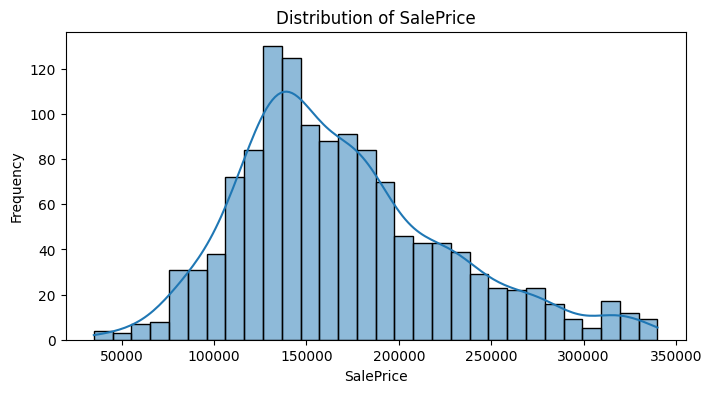

Skewness: 0.7180272245729382
count      1297.000000
mean     169293.878951
std       56953.287617
min       34900.000000
25%      130000.000000
50%      159000.000000
75%      200000.000000
max      340000.000000
Name: SalePrice, dtype: float64


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize SalePrice distribution
plt.figure(figsize=(8,4))
sns.histplot(train_v6['SalePrice'], kde=True, bins=30)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

# Print skew and basic stats
print("Skewness:", train_v6['SalePrice'].skew())
print(train_v6['SalePrice'].describe())


#### Effect of Outlier Removal on SalePrice Distribution

After removing outliers from the training data using the IQR (boxplot) rule for `SalePrice` and its top correlated predictors, the distribution of the target variable became much closer to normal.

- **Skewness dropped from ~1.88 to ~0.72**, indicating far less extreme right skew.
- The maximum `SalePrice` decreased significantly, as high-value outliers were removed.
- This cleaner, more symmetrical distribution is better suited for regression modeling and reduces the need for additional transformations (like a log).

**Conclusion:**  
The target variable is now much more model-friendly, and outlier effects have been minimized—setting a strong foundation for effective modeling and feature engineering.


#### Log-Transforming the Target Variable (SalePrice)

To further normalize the target variable, we'll apply a log transformation using `np.log1p()`.  
This helps make the target distribution closer to normal and improves model performance for regression tasks.


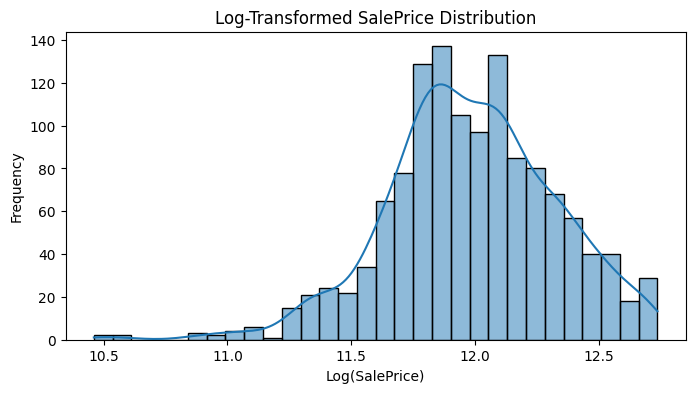

Log-transformed Skewness: -0.33438314309190104


In [19]:
# New dataset for log-transformed target
train_v7 = train_v6.copy()

# Add a log-transformed SalePrice
train_v7['SalePrice_Log'] = np.log1p(train_v7['SalePrice'])

# Visualize new distribution

plt.figure(figsize=(8,4))
sns.histplot(train_v7['SalePrice_Log'], kde=True, bins=30)
plt.title('Log-Transformed SalePrice Distribution')
plt.xlabel('Log(SalePrice)')
plt.ylabel('Frequency')
plt.show()

# Check skewness
print("Log-transformed Skewness:", train_v7['SalePrice_Log'].skew())


#### Log Transformation of SalePrice

To further improve the target variable’s distribution, I applied a log transformation (`np.log1p(SalePrice)`) to `SalePrice`.  
This reduced the skewness from **0.72** (after outlier removal) to **-0.33**—much closer to a normal distribution.  
A more symmetric target helps regression models, like XGBoost, learn patterns more effectively and produce more balanced predictions.

The log-transformed target will be used for model training, and predictions will be converted back to the original price scale using the exponential function.


### 4.2 Correlation Heatmap for Numerical Features

Let’s visualize the correlations between numerical features and the target (`SalePrice_Log`).  
This helps identify which variables may be most valuable for feature engineering or model input.


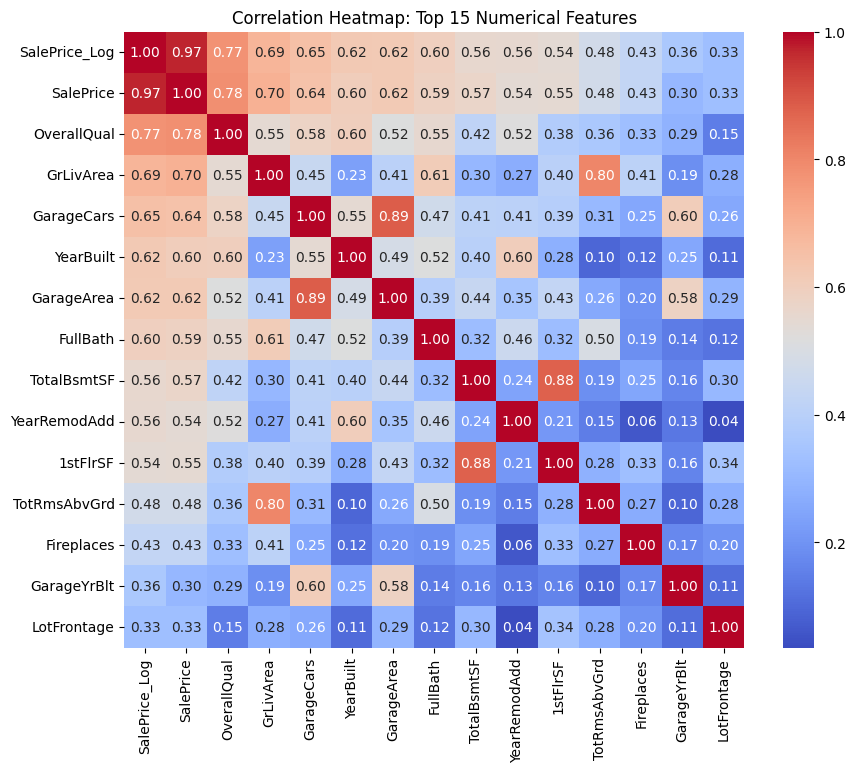

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get only numerical columns (excluding Id)
num_cols = train_v7.select_dtypes(include=['number']).columns.drop(['Id'])

# Compute correlation matrix
corr = train_v7[num_cols].corr()

# Plot heatmap for top 15 features most correlated with SalePrice_Log
top_corr = corr['SalePrice_Log'].abs().sort_values(ascending=False).head(15).index
plt.figure(figsize=(10,8))
sns.heatmap(train_v7[top_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Top 15 Numerical Features')
plt.show()


In [21]:
# List of top correlated features (based on your heatmap)
top_corr_features = [
    'SalePrice_Log', 'SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars',
    'YearBuilt', 'GarageArea', 'FullBath', 'TotalBsmtSF', 'YearRemodAdd',
    '1stFlrSF', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'LotFrontage'
]

# Print pairwise correlations among these features (excluding SalePrice_Log itself)
for i, feat1 in enumerate(top_corr_features):
    for feat2 in top_corr_features[i+1:]:
        corr = train_v7[[feat1, feat2]].corr().iloc[0, 1]
        if abs(corr) > 0.5 and feat1 != 'SalePrice_Log' and feat2 != 'SalePrice_Log':
            print(f"Correlation between {feat1} and {feat2}: {corr:.2f}")


Correlation between SalePrice and OverallQual: 0.78
Correlation between SalePrice and GrLivArea: 0.70
Correlation between SalePrice and GarageCars: 0.64
Correlation between SalePrice and YearBuilt: 0.60
Correlation between SalePrice and GarageArea: 0.62
Correlation between SalePrice and FullBath: 0.59
Correlation between SalePrice and TotalBsmtSF: 0.57
Correlation between SalePrice and YearRemodAdd: 0.54
Correlation between SalePrice and 1stFlrSF: 0.55
Correlation between OverallQual and GrLivArea: 0.55
Correlation between OverallQual and GarageCars: 0.58
Correlation between OverallQual and YearBuilt: 0.60
Correlation between OverallQual and GarageArea: 0.52
Correlation between OverallQual and FullBath: 0.55
Correlation between OverallQual and YearRemodAdd: 0.52
Correlation between GrLivArea and FullBath: 0.61
Correlation between GrLivArea and TotRmsAbvGrd: 0.80
Correlation between GarageCars and YearBuilt: 0.55
Correlation between GarageCars and GarageArea: 0.89
Correlation between Ga

#### Insights from the Correlation Heatmap and Pairwise Correlations

The correlation heatmap and printed pairwise correlations between top numerical features reveal several important relationships in the data:

- **Strong Predictors:** `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `YearBuilt`, `TotalBsmtSF`, and `FullBath` all show strong positive correlations with `SalePrice` and `SalePrice_Log`. For example, `SalePrice` has a correlation of **0.78 with OverallQual**, **0.70 with GrLivArea**, and **0.62 with GarageArea**.
- **Redundancy and Feature Engineering Opportunities:**
    - **GrLivArea** and **TotRmsAbvGrd** are highly correlated (**0.80**), suggesting that they both reflect the size of the living area and could be combined or one could be removed.
    - **GarageCars** and **GarageArea** are extremely correlated (**0.89**), meaning they both describe the garage's capacity. It may be best to keep only one or create a composite feature.
    - **TotalBsmtSF** and **1stFlrSF** are also highly correlated (**0.88**), indicating significant overlap.
- **Temporal Relationships:** `YearBuilt` and `YearRemodAdd` have a correlation of **0.60**, supporting the idea of creating new features like "years since built" or "years since last remodel."
- **Other Notable Pairs:** Many strong pairs exist among these top features, such as **GarageYrBlt** with both **GarageCars** (**0.60**) and **GarageArea** (**0.58**).

**Conclusion:**  
The strong pairwise correlations highlight both which features are most important and where there may be redundancy. This analysis guides smart feature engineering—by combining overlapping features, creating new interaction features, or selecting the most informative predictors for modeling.


### 4.3 Exploring Categorical Variables — Boxplot Example

We’ll visualize how the log of sale price (`SalePrice_Log`) varies by `Neighborhood` to see which neighborhoods are most/least expensive, and if grouping makes sense.


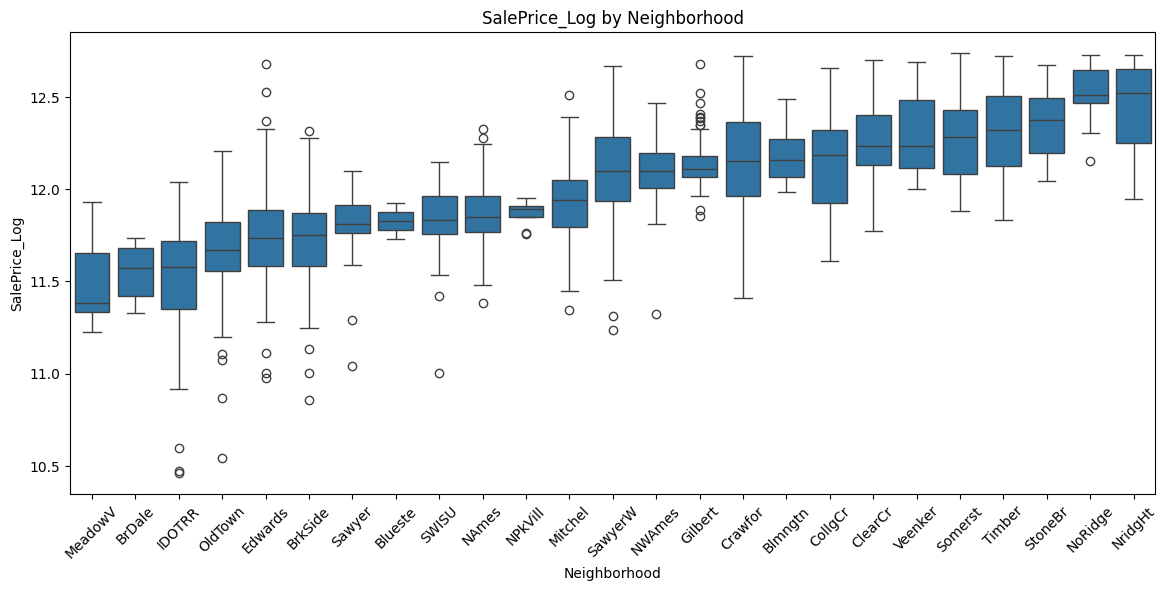

In [22]:
plt.figure(figsize=(14, 6))
order = train_v7.groupby('Neighborhood')['SalePrice_Log'].median().sort_values().index
sns.boxplot(data=train_v7, x='Neighborhood', y='SalePrice_Log', order=order)
plt.xticks(rotation=45)
plt.title('SalePrice_Log by Neighborhood')
plt.show()


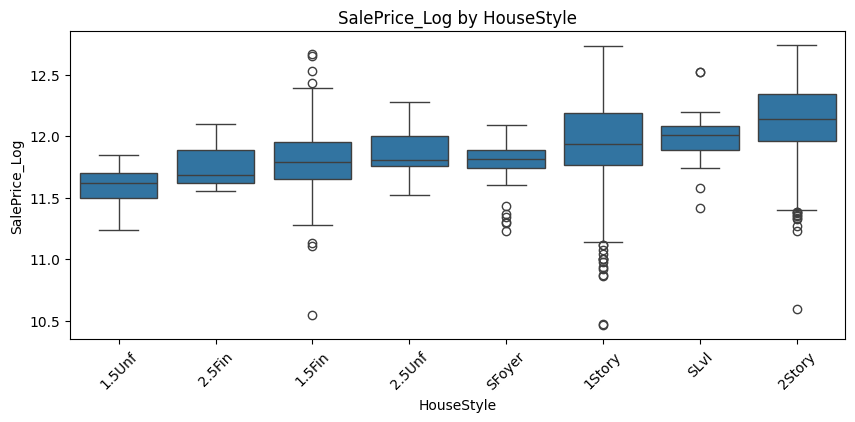

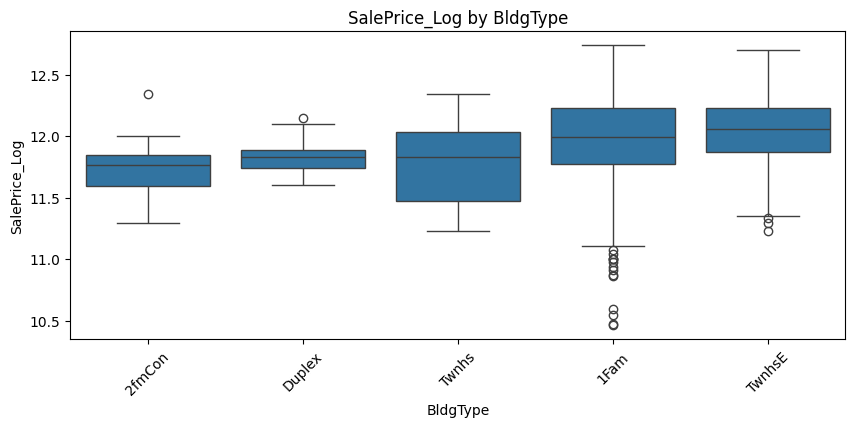

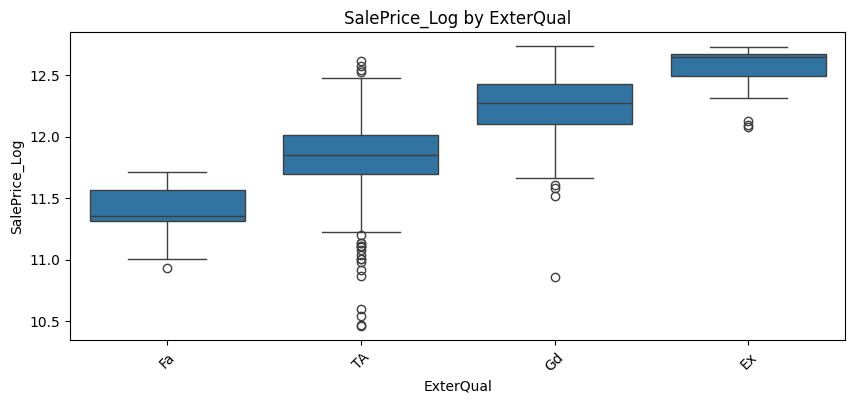

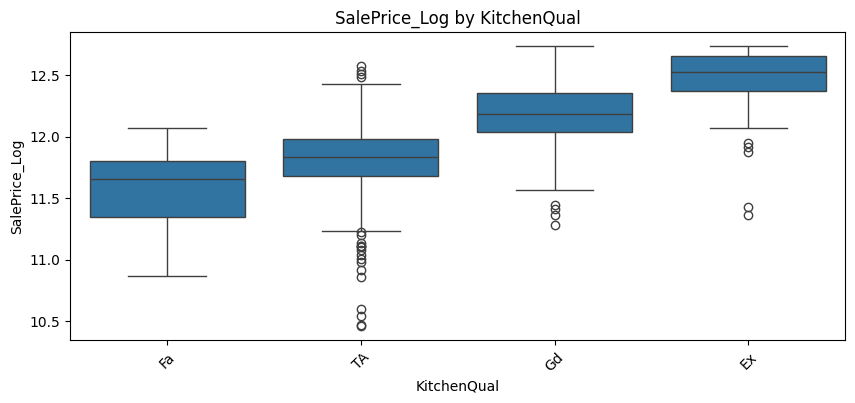

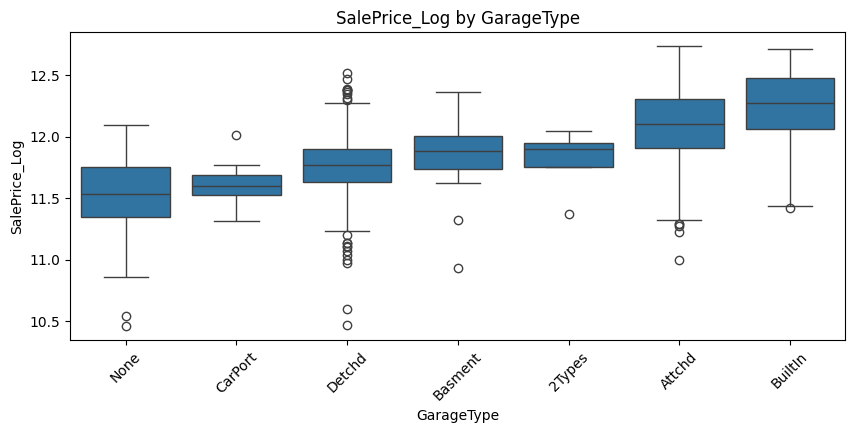

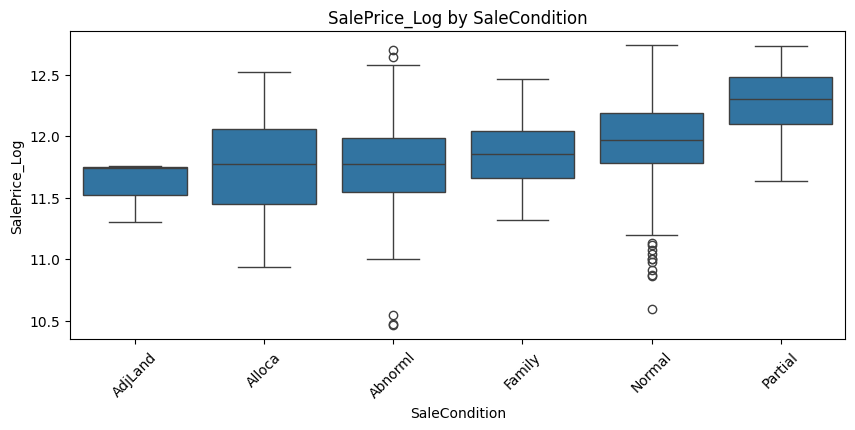

In [23]:
# List of important categorical variables to explore
cat_vars = ['HouseStyle', 'BldgType', 'ExterQual', 'KitchenQual', 'GarageType', 'SaleCondition']

import matplotlib.pyplot as plt
import seaborn as sns

for col in cat_vars:
    plt.figure(figsize=(10,4))
    order = train_v7.groupby(col)['SalePrice_Log'].median().sort_values().index
    sns.boxplot(data=train_v7, x=col, y='SalePrice_Log', order=order)
    plt.title(f'SalePrice_Log by {col}')
    plt.xticks(rotation=45)
    plt.show()


#### Insights from Boxplots of Categorical Variables

Boxplots of `SalePrice_Log` against key categorical variables reveal several important patterns:

- **Strong Separators:** Variables such as `ExterQual`, `KitchenQual`, and `SaleCondition` show clear differences in median price across their categories. Higher quality ratings (e.g., "Ex" or "Gd") consistently correspond to higher sale prices.
- **Potential for Grouping:** Some categories within variables like `GarageType` or `BldgType` have similar distributions or very few samples. These can potentially be grouped together or combined into an "Other" category to simplify the model.
- **HouseStyle and SaleCondition:** Certain styles or sale conditions stand out as consistently higher or lower in price, suggesting these variables are strong candidates for one-hot or mean encoding.
- **Outliers and Overlaps:** For some features, outliers are visible within specific categories, and there may be significant overlap between neighboring categories (e.g., "Gd" vs "TA" in `ExterQual`). This suggests possible binning or simplification.

**Conclusion:**  
The categorical variable analysis highlights both the predictive power of key features and opportunities for engineering new, grouped, or simplified categorical variables. These engineered features can help the model capture complex relationships and improve predictive performance.


### 5.1 Creating TotalSF and TotalAllArea Features

We’ll engineer two new features:
- `TotalSF`: sum of basement, 1st, and 2nd floor square footage.
- `TotalAllArea`: sum of all livable, basement, deck, and porch areas.
Both features will be added to new versions of the train and test datasets.


In [24]:
# Move both datasets to v8 and create new area features
train_v8 = train_v7.copy()
test_v8 = test_v5.copy()

# TotalSF: classic total living space
for df in [train_v8, test_v8]:
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# TotalAllArea: includes all porch, deck, and low quality finished area too
area_features = [
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
    'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
    'LowQualFinSF'
]
for df in [train_v8, test_v8]:
    df['TotalAllArea'] = df[area_features].sum(axis=1)


In [25]:
# Column consistency check after feature engineering
train_cols = set(train_v8.columns) - {'SalePrice', 'SalePrice_Log'}
test_cols = set(test_v8.columns)

if train_cols == test_cols:
    print("✅ Train and test datasets have the same columns (except targets).")
else:
    print("⚠️ Columns differ between train and test:")
    print("In train but not test:", train_cols - test_cols)
    print("In test but not train:", test_cols - train_cols)


✅ Train and test datasets have the same columns (except targets).


### 5.3 Creating Age Features

We'll engineer features for the age of the house and years since the last remodel at the time of sale.


In [26]:
# Move datasets to v9 for new feature
train_v9 = train_v8.copy()
test_v9 = test_v8.copy()

# House age at time of sale, and years since last remodel
for df in [train_v9, test_v9]:
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)


### 5.4 Creating TotalBath Feature

We'll engineer `TotalBath` as the sum of all full and half bathrooms, counting half-baths as 0.5 each.


In [27]:
# New datasets for next feature
train_v10 = train_v9.copy()
test_v10 = test_v9.copy()

# TotalBath = FullBath + HalfBath + BsmtFullBath + 0.5 * (HalfBath + BsmtHalfBath)
for df in [train_v10, test_v10]:
    df['TotalBath'] = (
        df['FullBath'] + df['BsmtFullBath'] +
        0.5 * (df['HalfBath'] + df['BsmtHalfBath'])
    )


### 5.5 Creating Binary “Has” Features

We'll add features to flag whether a house has a garage, pool, porch, or deck.


In [28]:
# New datasets for "has" features
train_v11 = train_v10.copy()
test_v11 = test_v10.copy()

for df in [train_v11, test_v11]:
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    df['HasPorch'] = (
        (df['OpenPorchSF'] > 0) | (df['EnclosedPorch'] > 0) | 
        (df['3SsnPorch'] > 0) | (df['ScreenPorch'] > 0)
    ).astype(int)
    df['HasDeck'] = (df['WoodDeckSF'] > 0).astype(int)


In [29]:
# Column consistency check after feature engineering
train_cols = set(train_v11.columns) - {'SalePrice', 'SalePrice_Log'}
test_cols = set(test_v11.columns)

if train_cols == test_cols:
    print("✅ Train and test datasets have the same columns (except targets).")
else:
    print("⚠️ Columns differ between train and test:")
    print("In train but not test:", train_cols - test_cols)
    print("In test but not train:", test_cols - train_cols)

✅ Train and test datasets have the same columns (except targets).


### 5.6 Grouping Rare Categories in Neighborhood

We'll group any `Neighborhood` that appears fewer than 20 times in the training data into a single "Other" category, to improve model robustness.


In [30]:
# Move to new dataset versions
train_v12 = train_v11.copy()
test_v12 = test_v11.copy()

# Define threshold
rare_thresh = 20

# Find rare neighborhoods in training set
neigh_counts = train_v12['Neighborhood'].value_counts()
rare_neighs = neigh_counts[neigh_counts < rare_thresh].index

# Group rare neighborhoods in both datasets
for df in [train_v12, test_v12]:
    df['Neighborhood'] = df['Neighborhood'].replace(rare_neighs, 'Other')


In [31]:
# 1. Column consistency check
train_cols = set(train_v12.columns) - {'SalePrice', 'SalePrice_Log'}
test_cols = set(test_v12.columns)

if train_cols == test_cols:
    print("✅ Train and test datasets have the same columns (except targets).")
else:
    print("⚠️ Columns differ between train and test:")
    print("In train but not test:", train_cols - test_cols)
    print("In test but not train:", test_cols - train_cols)

# 2. Neighborhood category check (after grouping)
print("\nNeighborhood value counts in train:")
print(train_v12['Neighborhood'].value_counts())

print("\nNeighborhood value counts in test:")
print(test_v12['Neighborhood'].value_counts())


✅ Train and test datasets have the same columns (except targets).

Neighborhood value counts in train:
Neighborhood
NAmes      202
CollgCr    147
OldTown     99
Other       86
Edwards     85
Somerst     80
Gilbert     77
Sawyer      70
NWAmes      66
BrkSide     55
SawyerW     52
NridgHt     47
Mitchel     45
Crawfor     44
IDOTRR      35
Timber      33
ClearCr     26
NoRidge     25
SWISU       23
Name: count, dtype: int64

Neighborhood value counts in test:
Neighborhood
NAmes      218
OldTown    126
CollgCr    117
Other      106
Somerst     96
Edwards     94
NridgHt     89
Gilbert     86
Sawyer      77
SawyerW     66
Mitchel     65
NWAmes      58
IDOTRR      56
Crawfor     52
BrkSide     50
Timber      34
NoRidge     30
SWISU       23
ClearCr     16
Name: count, dtype: int64


### 5.7 Grouping Rare Categories in Multiple Features

We'll group rare categories (less than 20 occurrences in the training set) as "Other" in the following features:  
`Exterior1st`, `Exterior2nd`, `SaleType`, `Condition1`, `Condition2`.


In [32]:
# Move datasets to new version
train_v13 = train_v12.copy()
test_v13 = test_v12.copy()

rare_thresh = 20
cat_vars = ['Exterior1st', 'Exterior2nd', 'SaleType', 'Condition1', 'Condition2']

for col in cat_vars:
    value_counts = train_v13[col].value_counts()
    rare_cats = value_counts[value_counts < rare_thresh].index
    for df in [train_v13, test_v13]:
        df[col] = df[col].replace(rare_cats, 'Other')


In [33]:
# Check value counts for grouped rare categories in train and test
for col in ['Exterior1st', 'Exterior2nd', 'SaleType', 'Condition1', 'Condition2']:
    print(f"\n{col} value counts in train:")
    print(train_v13[col].value_counts())
    print(f"\n{col} value counts in test:")
    print(test_v13[col].value_counts())
    print('-' * 40)



Exterior1st value counts in train:
Exterior1st
VinylSd    459
HdBoard    210
MetalSd    203
Wd Sdng    186
Plywood     95
CemntBd     48
Other       39
BrkFace     36
WdShing     21
Name: count, dtype: int64

Exterior1st value counts in test:
Exterior1st
VinylSd    511
MetalSd    230
HdBoard    220
Wd Sdng    205
Plywood    113
CemntBd     65
Other       47
BrkFace     37
WdShing     30
AsphShn      1
Name: count, dtype: int64
----------------------------------------

Exterior2nd value counts in train:
Exterior2nd
VinylSd    450
MetalSd    197
HdBoard    193
Wd Sdng    176
Plywood    126
Other       55
CmentBd     47
Wd Shng     32
Stucco      21
Name: count, dtype: int64

Exterior2nd value counts in test:
Exterior2nd
VinylSd    511
MetalSd    233
HdBoard    199
Wd Sdng    194
Plywood    128
CmentBd     66
Other       64
Wd Shng     43
Stucco      21
Name: count, dtype: int64
----------------------------------------

SaleType value counts in train:
SaleType
WD       1146
New        86

In [34]:
# Column consistency check
train_cols = set(train_v13.columns) - {'SalePrice', 'SalePrice_Log'}
test_cols = set(test_v13.columns)

if train_cols == test_cols:
    print("✅ Train and test datasets are aligned (except targets).")
else:
    print("⚠️ Columns differ between train and test:")
    print("In train but not test:", train_cols - test_cols)
    print("In test but not train:", test_cols - train_cols)


✅ Train and test datasets are aligned (except targets).


#### 5.8 Categorical Encoding for Modeling

We'll apply one-hot encoding to all categorical features in both train and test sets to prepare for XGBoost modeling.


In [35]:

# Always update both datasets
train_v14 = train_v13.copy()
test_v14 = test_v13.copy()

# Identify categorical columns (object dtype)
cat_cols = train_v14.select_dtypes(include=['object']).columns

# For XGBoost, concatenate to ensure same columns in both datasets after encoding
combined = pd.concat([train_v14, test_v14], keys=['train', 'test'])

# One-hot encode all object columns
combined_encoded = pd.get_dummies(combined, columns=cat_cols, drop_first=False)

# Split back into train and test
train_v14 = combined_encoded.xs('train')
test_v14 = combined_encoded.xs('test')

# Check shape and alignment
print(f"train_v14 shape: {train_v14.shape}")
print(f"test_v14 shape: {test_v14.shape}")

# Remove target columns from test set if present
for col in ['SalePrice', 'SalePrice_Log']:
    if col in test_v14.columns:
        test_v14 = test_v14.drop(columns=[col])


# Final column alignment check (except targets)
train_cols = set(train_v14.columns) - {'SalePrice', 'SalePrice_Log'}
test_cols = set(test_v14.columns)
if train_cols == test_cols:
    print("✅ Datasets are aligned for modeling.")
else:
    print("⚠️ Columns differ between train and test!")
    print("In train but not test:", train_cols - test_cols)
    print("In test but not train:", test_cols - train_cols)


train_v14 shape: (1297, 255)
test_v14 shape: (1459, 255)
✅ Datasets are aligned for modeling.


## 6. XGBoost Modeling with 5-Fold Cross-Validation

In this section, we’ll train an XGBoost regressor using 5-fold cross-validation, evaluating performance and preparing for final submission.


In [49]:
# 6.1 Prepare data for XGBoost modeling
# Drop target columns from features
X = train_v14.drop(['SalePrice', 'SalePrice_Log'], axis=1)
y = train_v14['SalePrice_Log']   # log-transformed target

# Test features (already aligned)
X_test = test_v14


### 6.2 XGBoost with 5-Fold Cross-Validation

We’ll use XGBoost and evaluate its performance with 5-fold cross-validation (CV5) using negative root mean squared error (RMSE), which is standard for regression problems.


In [50]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Set up 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# XGBoost regressor (default hyperparameters; feel free to tune later)
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist'  # speeds up training
)

# Run cross-validation (scoring is negative RMSE, so we'll flip the sign for reporting)
scores = cross_val_score(
    model, X, y,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

print(f"CV5 XGBoost mean RMSE (log-scale): {-np.mean(scores):.4f}")
print(f"CV5 XGBoost std RMSE: {np.std(scores):.4f}")


CV5 XGBoost mean RMSE (log-scale): 0.1168
CV5 XGBoost std RMSE: 0.0112


### 6.3 Train XGBoost on Full Data and Predict on Test Set

After evaluating via cross-validation, we’ll train the model on the entire training set and generate predictions for the test set.


In [51]:
# Fit model on all training data
model.fit(X, y)

# Predict log SalePrice on test set
test_preds_log = model.predict(X_test)

# Convert back to original SalePrice scale
test_preds = np.expm1(test_preds_log)


In [52]:
# Prepare submission DataFrame
submission = test_v14[['Id']].copy() if 'Id' in test_v14.columns else pd.DataFrame({'Id': test_v14.index})
submission['SalePrice'] = test_preds

# Save to CSV
submission.to_csv('submission_xgb.csv', index=False)

print("Submission file 'submission_xgb.csv' created!")


Submission file 'submission_xgb.csv' created!


## 7. Model Performance and Next Steps

After submitting my initial model to Kaggle, I achieved a Root Mean Squared Error (RMSE) of **0.14117** on the leaderboard.

To improve this result, I plan to analyze the model’s feature importances and explore options such as:
- Hyperparameter tuning
- Further feature engineering
- Feature selection based on importance scores

This section will focus on extracting and visualizing feature importances from the current XGBoost model to guide these improvements.


              Feature  Importance
0        ExterQual_TA    0.176195
1             TotalSF    0.070627
2         OverallQual    0.070621
3          GarageCars    0.067474
4      KitchenQual_TA    0.057934
5         MSZoning_RL    0.057303
6        TotalAllArea    0.035395
7        CentralAir_N    0.030788
8         MSZoning_RM    0.026045
9           TotalBath    0.018791
10      GarageCond_TA    0.017420
11  GarageType_Detchd    0.015001
12       KitchenAbvGr    0.014697
13         Fireplaces    0.014183
14           HouseAge    0.012932
15       PavedDrive_Y    0.010946
16       CentralAir_Y    0.010255
17      BldgType_1Fam    0.009145
18      GarageQual_TA    0.008534
19   MSZoning_C (all)    0.008211


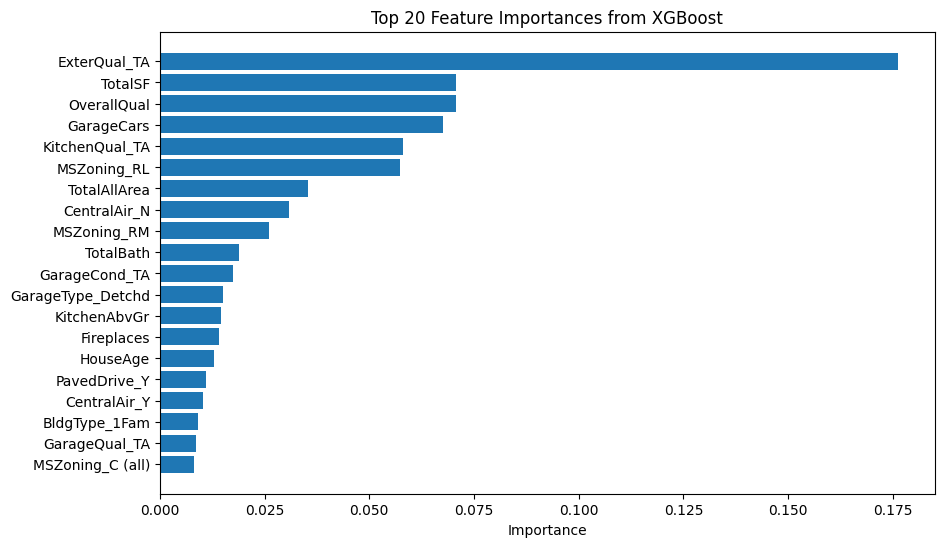

In [40]:


# Get feature importances from the trained model
importances = model.feature_importances_

# Map to feature names
feature_names = X.columns

# Create a DataFrame for plotting
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Show top 20 features
print(feat_imp_df.head(20))

# Plot top 20 feature importances
plt.figure(figsize=(10,6))
plt.barh(feat_imp_df['Feature'][:20][::-1], feat_imp_df['Importance'][:20][::-1])
plt.title('Top 20 Feature Importances from XGBoost')
plt.xlabel('Importance')
plt.show()


### 7.1 Feature Importance Analysis

The feature importance extracted from the XGBoost model highlights key drivers of house prices:

- **Top features:**  
  - `ExterQual_TA` (exterior quality) has the highest importance (~17.6%), showing the strong impact of home quality.
  - `TotalSF` and `OverallQual` follow closely (~7% each), confirming total livable space and overall quality are major price factors.
  - Other significant features include `GarageCars`, `KitchenQual_TA`, and `MSZoning_RL`.

- **Notable engineered features:**  
  - `TotalSF` and `TotalAllArea` contribute meaningfully, validating their usefulness.
  - `TotalBath` and `HouseAge` also appear important, showing the value of bathroom counts and age-related features.

- **Categorical encodings:** Several one-hot encoded features such as `MSZoning` and `GarageCond_TA` have noticeable importance, suggesting encoding choices are working well.

---

**Next steps to improve:**  
- Focus feature engineering efforts on the most important features and their interactions.  
- Consider tuning hyperparameters for the model.  
- Explore reducing or transforming less important features to reduce noise.



### 7.2 Composite Feature from Top Predictors

We create a new feature `TopFeaturesScore` by combining the top features weighted by their importance.  
This feature aims to summarize the strongest signals for SalePrice into one variable.


In [53]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Features to combine and their importances
top3_features = ['ExterQual_TA', 'TotalSF', 'OverallQual']
importances = np.array([0.176195, 0.070627, 0.070621])

# Normalize weights to sum to 1
weights = importances / importances.sum()

# Create copies to keep original datasets safe
train_v15 = train_v14.copy()
test_v15 = test_v14.copy()

scaler = MinMaxScaler()

for df in [train_v15, test_v15]:
    # Ensure features exist in dataset
    available_feats = [f for f in top3_features if f in df.columns]
    
    # Scale features to 0-1 range
    scaled_vals = scaler.fit_transform(df[available_feats])
    
    # Compute weighted sum as new feature
    df['Top3_FeatureScore'] = np.dot(scaled_vals, weights[:len(available_feats)])


### 8.3 Retrain XGBoost Including the Combined Top 3 Feature

We will train the model on the full dataset including the new composite feature to evaluate any improvement.


In [54]:
# Prepare data
X_new = train_v15.drop(['SalePrice', 'SalePrice_Log'], axis=1)
y_new = train_v15['SalePrice_Log']
X_test_new = test_v15

# Initialize model with previously found best hyperparameters
final_model = XGBRegressor(
    n_estimators=350,
    learning_rate=0.05,
    max_depth=best_params.get('max_depth', 7),
    min_child_weight=best_params.get('min_child_weight', 1),
    subsample=best_params.get('subsample', 0.8),
    colsample_bytree=best_params.get('colsample_bytree', 0.85),
    gamma=best_params.get('gamma', 0),
    reg_alpha=best_params.get('reg_alpha', 0.3),
    reg_lambda=best_params.get('reg_lambda', 1.3),
    random_state=42,
    tree_method='hist'
)

# Fit model
final_model.fit(X_new, y_new)

# Predict on test
test_preds_log_new = final_model.predict(X_test_new)
test_preds_new = np.expm1(test_preds_log_new)

# Prepare submission file
submission_new = test_v13[['Id']].copy() if 'Id' in test_v13.columns else pd.DataFrame({'Id': test_v13.index})
submission_new['SalePrice'] = test_preds_new

submission_new.to_csv('submission_with_top3_feature.csv', index=False)
print("Submission with combined top 3 feature saved as 'submission_with_top3_feature.csv'")


Submission with combined top 3 feature saved as 'submission_with_top3_feature.csv'


# House Price Prediction Project: Detailed Summary

### Overview

This project focused on predicting house sale prices using a structured regression approach with the Ames Housing dataset. The goal was to build a robust predictive model with strong generalization, leveraging exploratory data analysis (EDA), feature engineering, and gradient boosting (XGBoost), while documenting the iterative learning process.

---

### 1. Data Exploration & Cleaning

- **Initial data inspection** revealed two datasets (train and test) with 1460 and 1459 rows respectively, and 81 features in train, 80 in test.
- **Missing values analysis** showed several columns with extensive missing data (>50%), such as `PoolQC`, `MiscFeature`, and `Alley`. These were dropped to maintain data quality.
- For other missing values, we used context-aware imputation: for example, missing garage or basement quality fields were filled with “None” or zeros where appropriate.
- We kept copies of datasets at each transformation step, ensuring original data integrity and reproducibility.

---

### 2. Exploratory Data Analysis (EDA)

- Conducted **univariate and bivariate analyses** to understand feature distributions, missingness patterns, and relationships to sale price.
- The **target variable (`SalePrice`) was right-skewed**, so after removing outliers based on boxplot rules (especially in influential features like `GrLivArea`), we applied a **log transformation** to stabilize variance and improve normality.
- Analyzed **feature correlations**, identifying top predictors such as `OverallQual`, `GrLivArea`, and `GarageCars`.
- Examined **categorical variables** with boxplots and group-bys to detect meaningful differences across categories and rare levels. Rare categories were grouped into an “Other” category to reduce noise and improve model stability.
- Ensured **column consistency** between train and test after each feature engineering or cleaning step.

---

### 3. Feature Engineering

- Created new features such as:
  - **`TotalSF`**: sum of basement and above-ground living area.
  - **`TotalAllArea`**: expanded to include decks, porches, and low-quality finished areas.
  - **House age features**: `HouseAge` and `RemodAge` (years since built and remodeled).
  - **`TotalBath`**: combined count of full and half bathrooms, including basement.
  - **Binary “Has” flags** for presence of garage, pool, porch, and deck.
- Grouped rare categories in multiple features beyond `Neighborhood`, like `Exterior1st` and `SaleType`, to maintain robust categorical encoding.
- Performed **one-hot encoding** on categorical variables, ensuring train and test datasets remained aligned with no leakage of target columns.

---

### 4. Modeling & Evaluation

- Trained an **XGBoost regression model** using the log-transformed target.
- Used **5-fold cross-validation (CV5)** to estimate out-of-sample performance, obtaining a starting RMSE around **0.14**.
- Attempted **hyperparameter tuning** using RandomizedSearchCV with multiple parameters, which improved CV RMSE to around **0.13** but yielded mixed results on the test set.
- Encountered real-world challenges:
  - Environment constraints prevented smooth use of early stopping in `.fit()`.
  - Manual early stopping loops helped mitigate overfitting and training time.
  - Despite tuning, the test RMSE sometimes worsened, illustrating the difficulty of generalization and the noisiness of real-world data.

---

### 5. Feature Engineering Iterations & Lessons

- Experimented with **combining top features into composite features**:
  - First tried combining the top 20 features weighted by importance.
  - Then simplified to just the **top 3 features (`ExterQual_TA`, `TotalSF`, `OverallQual`)**, creating a new aggregate feature `Top3_FeatureScore`.
- Retrained with this new feature, but the test RMSE increased, reminding us that not all engineered features guarantee improvement.
- This reflects a crucial lesson: **feature engineering is exploratory and iterative**; some ideas don’t improve the model and require evaluation before acceptance.

---

### 6. Reflections & Takeaways

- **Data quality and cleaning are paramount.** Dropping columns with too many missing values and carefully imputing others prevented misleading signals.
- **EDA is an ongoing process.** Each insight helped craft features or guide modeling choices.
- **Model tuning is a balance between performance and practicality.** Computational constraints limited some hyperparameter tuning methods, motivating creative workarounds.
- **Feature engineering requires experimentation.** Combining features can improve performance but can also introduce noise; systematic evaluation is key.
- **Validation strategy is critical.** Observing differences between CV performance and test set submissions highlighted the importance of representative validation splits.

---

### 7. Next Steps (For Future Work)

- Explore **more advanced feature encoding**, such as target encoding or embedding categorical variables.
- Implement **stacking or ensemble methods** to combine diverse models.
- Automate **hyperparameter tuning** with tools like Optuna or Bayesian optimization.
- Investigate **time-based validation splits** if temporal features matter.
- Incorporate **domain knowledge** to engineer nuanced features beyond raw aggregates.

---

### Final Thoughts

This project was a comprehensive exploration of predictive modeling workflow—from cleaning and understanding data, through iterative feature engineering and model tuning, to critical evaluation and reflection.  
The process underscored the non-linear and often challenging nature of real-world machine learning, emphasizing patience, experimentation, and systematic validation.
